In [8]:
'''Download a sample credit card fraud dataset (with imbalanced classes) from Kaggle or UCI, split it into train and test sets, and train a logistic regression classifier using scikit-learn.'''

import pandas as pd

df = pd.read_csv("creditcard.csv")

print(df.head())
print(df.shape)

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (227845, 30)
Testing data: (56962, 30)


In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(y_pred[:20])

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

[0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     56864
           1       0.05      0.91      0.09        98

    accuracy                           0.97     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.97      0.98     56962



C:\Users\Rdvel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


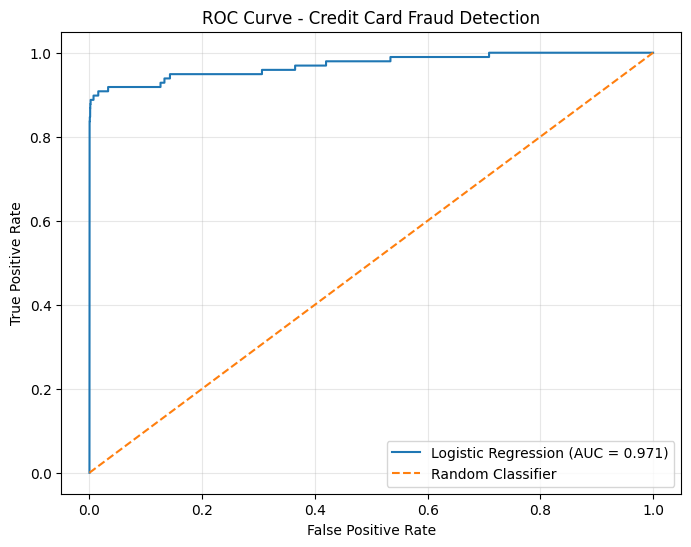

In [11]:
'''Plot the ROC curve for your classifier using sklearn.metrics.roc_curve and matplotlib, and display the AUC score on the plot.'''

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Get probability of fraud (Class = 1)
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Credit Card Fraud Detection")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

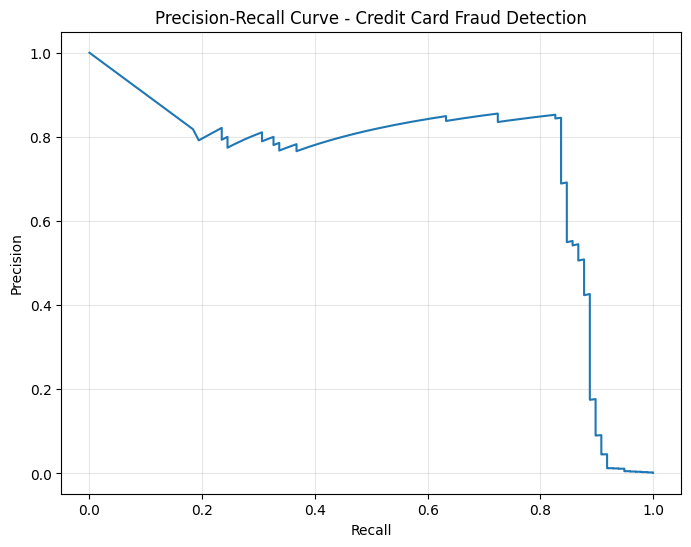

'The Precision-Recall curve helps evaluate fraud detection on imbalanced data by showing the trade-off between detecting more fraudulent transactions (recall) and avoiding false fraud alerts (precision).'

In [12]:
'''Plot the Precision-Recall curve for your model using sklearn.metrics.precision_recall_curve and matplotlib, and explain in one line why this curve is useful for imbalanced datasets.<br><br><em><strong>Hint:</strong> Focus on how precision and recall behave when the positive class is rare.</em>'''

import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Get probability predictions for the positive class (Fraud = 1)
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate precision and recall
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Credit Card Fraud Detection")

plt.grid(alpha=0.3)
plt.show()

'''The Precision-Recall curve helps evaluate fraud detection on imbalanced data by showing the trade-off between detecting more fraudulent transactions (recall) and avoiding false fraud alerts (precision).'''

In [13]:
'''Calculate the log loss (cross-entropy loss) for your test set predictions using sklearn.metrics.log_loss and print the result.'''

from sklearn.metrics import log_loss

# Get probability predictions
y_prob = model.predict_proba(X_test)

# Calculate Log Loss
loss = log_loss(y_test, y_prob)

print("Log Loss:", loss)
y_prob_fraud = model.predict_proba(X_test)[:, 1]

print(y_prob_fraud[:10])
model.predict_proba(X_test)

Log Loss: 0.12791491682732342
[1.70020964e-02 6.13825425e-02 6.10582918e-03 9.64399042e-03
 9.58117083e-01 1.32600235e-02 4.86708993e-04 1.82157702e-02
 1.21724129e-01 4.22021011e-03]


array([[9.82997904e-01, 1.70020964e-02],
       [9.38617457e-01, 6.13825425e-02],
       [9.93894171e-01, 6.10582918e-03],
       ...,
       [9.99835543e-01, 1.64456856e-04],
       [9.97108472e-01, 2.89152797e-03],
       [9.13022670e-01, 8.69773305e-02]], shape=(56962, 2))

In [14]:
'''Change the class distribution in your test set to be even more imbalanced (e.g., only 2% positive class), re-calculate accuracy, AUC, and log loss, and write 2 lines explaining which metric is most misleading and why.<br><br><em><strong>Hint:</strong> Accuracy can be high even if the model ignores the minority class.</em>'''

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

# Get probabilities from the existing model
y_prob_all = model.predict_proba(X_test)[:, 1]

# Separate positive (fraud) and negative (not fraud) samples
positive_indices = np.where(y_test.values == 1)[0]
negative_indices = np.where(y_test.values == 0)[0]

# Keep all fraud cases
n_positive = len(positive_indices)

# Select enough negative cases to make fraud approximately 2%
n_negative = int(n_positive * 98 / 2)

# Make sure we don't select more negatives than available
n_negative = min(n_negative, len(negative_indices))

# Randomly select negative cases
np.random.seed(42)
selected_negative = np.random.choice(
    negative_indices,
    size=n_negative,
    replace=False
)

# Combine positive and negative indices
selected_indices = np.concatenate([
    positive_indices,
    selected_negative
])

# Create the new 2% imbalanced test set
y_test_2 = y_test.iloc[selected_indices]
y_prob_2 = y_prob_all[selected_indices]

# Convert probabilities into class predictions
y_pred_2 = (y_prob_2 >= 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test_2, y_pred_2)
auc = roc_auc_score(y_test_2, y_prob_2)
loss = log_loss(y_test_2, np.column_stack([1 - y_prob_2, y_prob_2]))

print("Positive class percentage:",
      round(y_test_2.mean() * 100, 2), "%")

print("Accuracy:", accuracy)
print("AUC:", auc)
print("Log Loss:", loss)

'''Accuracy is the most misleading metric for a highly imbalanced dataset because a model can achieve very high accuracy simply by predicting the majority class.
AUC and Log Loss are more informative because they evaluate the model's ability to distinguish classes and the quality of its probability predictions.'''

Positive class percentage: 2.0 %
Accuracy: 0.9675510204081633
AUC: 0.970666983994764
Log Loss: 0.13848841840101336
